In this project (Title)
- We work to Identify the different type of audio classes in a Sound
- It is first Step for Miner Project
- **By Shourya Basu**

## **Introduction To Project**
###### **Aim**
To detect and Classsify the audio Classes in a Mix Sound of Traffic

The Classes are
- Vehicle horn
- Siren (ambulance, police, fire truck) 🚑🚓
- Engine noise


##### **Brief About Model using in This Project**

## Flow
Dataset -> MFCC + ZCR -> ELM(ML MODEL) -> Test

#### **Requriment**

#### **Dataset**
1. UrbanSound8K ()
2. sireNNet: Siren Classification Dataset


**Author :-** Shourya Basu


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


In [2]:
# Audio parameters
SAMPLE_RATE = 16000
N_MFCC = 13
FRAME_LENGTH = int(0.025 * SAMPLE_RATE)   # 400
HOP_LENGTH = int(0.010 * SAMPLE_RATE)     # 160
N_FFT = 512


def extract_features(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)

        # Skip extremely short clips
        if len(y) < 0.1 * sr:   # < 100 ms
            return None

        # Pre-emphasis
        y = np.append(y[0], y[1:] - 0.97 * y[:-1])

        # MFCC
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            win_length=FRAME_LENGTH,
            hop_length=HOP_LENGTH,
            window="hamming"
        )

        # Delta MFCC (SAFE width)
        mfcc_delta = librosa.feature.delta(mfcc, width=3)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2, width=3)

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(
            y,
            frame_length=FRAME_LENGTH,
            hop_length=HOP_LENGTH
        )

        # Combine features
        features = np.vstack([mfcc, mfcc_delta, mfcc_delta2, zcr])

        # Temporal pooling
        feature_vector = np.hstack([
            np.mean(features, axis=1),
            np.std(features, axis=1)
        ])

        return feature_vector

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [3]:
# Load CSV
df = pd.read_csv("dataset_labels.csv")

X = []
y = []

for _, row in df.iterrows():
    features = extract_features(row["filepath"])

    if features is None:
        continue

    X.append(features)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (4098, 80)
Label vector shape: (4098,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (3278, 80)
Test size: (820, 80)


ELM MODEL

In [6]:
class ELM:
    def __init__(self, input_size, hidden_size=300):
        self.W = np.random.randn(input_size, hidden_size)
        self.b = np.random.randn(hidden_size)

    def _sigmoid(self, x):
        x = np.clip(x, -50, 50)
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        H = self._sigmoid(X @ self.W + self.b)
        self.beta = np.linalg.pinv(H) @ y

    def predict_class(self, X, threshold=0.5):
        H = self._sigmoid(X @ self.W + self.b)
        y_pred = H @ self.beta
        return (y_pred >= threshold).astype(int)



In [7]:
elm = ELM(input_size=X_train.shape[1], hidden_size=300)
elm.fit(X_train, y_train)

print("ELM training completed")


ELM training completed


In [8]:
y_pred = elm.predict_class(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Accuracy: 0.974390243902439

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       569
           1       0.98      0.94      0.96       251

    accuracy                           0.97       820
   macro avg       0.98      0.96      0.97       820
weighted avg       0.97      0.97      0.97       820

Confusion Matrix:
 [[564   5]
 [ 16 235]]


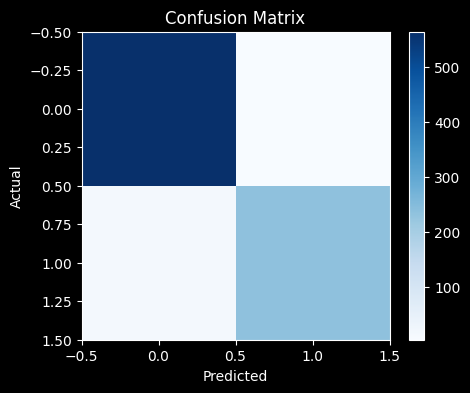

In [9]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

testing

In [17]:
# Path to local test audio
test_audio_path = "./Datasets/test_file_1(P).wav"

# Extract MFCC + ZCR features
feature = extract_features(test_audio_path)

if feature is None:
    print("Audio too short or invalid")
else:
    feature = feature.reshape(1, -1)

    # Predict
    prediction = elm.predict_class(feature, threshold=0.5)

    if prediction[0] == 1:
        print("Siren detected")
    else:
        print("No siren detected")


No siren detected




---


©️Copyright by Shourya Basu